In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))
import pandas as pd
import os
import torch

from torch.utils.data import DataLoader
from src.data.dataset import FacesDataset
from src.data.transforms import get_train_transform, get_test_transform

In [3]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

train_df["image_path"] = train_df["id"].apply(
    lambda x: os.path.join("../data/processed_64", f"face-{int(x)}.png")
)

test_df["image_path"] = test_df["id"].apply(
    lambda x: os.path.join("../data/processed_64", f"face-{int(x)}.png")
)

/tmp/ipykernel_4367/2460436623.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["image_path"] = train_df["id"].apply(
/tmp/ipykernel_4367/2460436623.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["image_path"] = test_df["id"].apply(


In [4]:
train_dataset = FacesDataset(train_df, transform=get_train_transform(64))
test_dataset = FacesDataset(test_df, transform=get_test_transform(64))

In [5]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

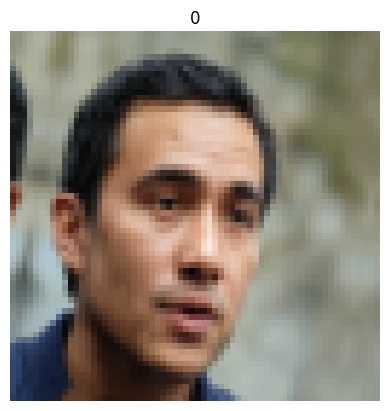

In [7]:
import matplotlib.pyplot as plt

img = images[0].permute(1, 2, 0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())

plt.imshow(img)
plt.title(labels[0].item())
plt.axis("off")

In [9]:
import torch
from src.models.vae import VAE
from src.training.train_vae import train_vae

device = "cuda" if torch.cuda.is_available() else "cpu"

# 🔷 Model
model = VAE(
    latent_dim=64,
    hidden_dims=[32, 64, 128],
    kernel_size=4,
    stride=2,
    padding=1,
    use_residual=True
).to(device)

# 🔷 Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss = train_vae(
    model,
    train_loader,
    optimizer,
    device,
    beta=0.01  # make sure train_vae accepts this
)


100%|██████████| 141/141 [00:06<00:00, 23.13it/s]


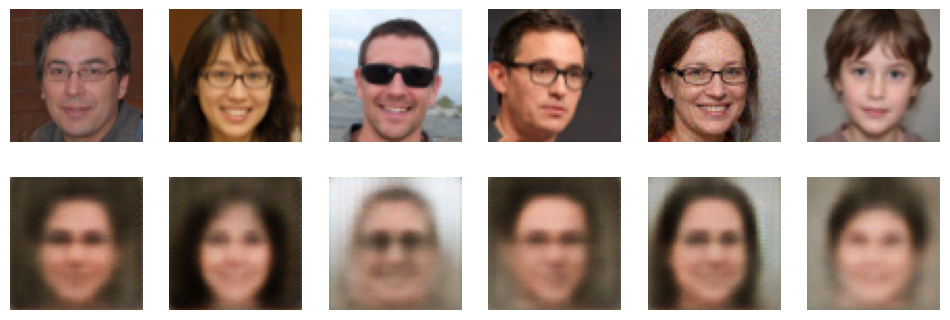

In [10]:
model.eval()

x, _ = next(iter(train_loader))
x = x.to(device)

with torch.no_grad():
    recon, _, _ = model(x)

import matplotlib.pyplot as plt

def show_images(original, reconstructed, n=6):
    original = original[:n].cpu().permute(0,2,3,1)
    reconstructed = reconstructed[:n].cpu().permute(0,2,3,1)

    fig, axes = plt.subplots(2, n, figsize=(12,4))

    for i in range(n):
        axes[0, i].imshow(original[i])
        axes[0, i].axis("off")

        axes[1, i].imshow(reconstructed[i])
        axes[1, i].axis("off")

    plt.show()

show_images(x, recon)

In [15]:
experiments = [
        ("baseline", dict(latent_dim=64, hidden_dims=[32,64,128], kernel_size=3, use_residual=False)),
        ("latent_128", dict(latent_dim=128, hidden_dims=[32,64,128], kernel_size=3, use_residual=False)),
        ("deep", dict(latent_dim=64, hidden_dims=[32,64,128,256], kernel_size=3, use_residual=False)),
        ("residual", dict(latent_dim=64, hidden_dims=[32,64,128], kernel_size=3, use_residual=True)),
        ("kernel_3", dict(latent_dim=64, hidden_dims=[32,64,128], kernel_size=4, use_residual=False)),
    ]

In [16]:
from src.evaluation.vae_visualize import evaluate_vae

results = []

for name, config in experiments:

    print(f"\n🚀 Running: {name}")

    # 🔷 Model
    model = VAE(**config).to(device)

    # 🔷 Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # 🔥 TRAIN (1 epoch ONLY — assignment requirement)
    loss = train_vae(
        model,
        train_loader,
        optimizer,
        device,
        beta=0.01
    )

    # 🔷 Evaluate (SSIM + save images)
    ssim_score = evaluate_vae(
        model,
        train_loader,
        device,
        latent_dim=config["latent_dim"],
        save_dir="../outputs/vae_images",
        name=name
    )

    results.append({
        "experiment": name,
        "latent_dim": config["latent_dim"],
        "depth": len(config["hidden_dims"]),
        "residual": config["use_residual"],
        "loss": loss,
        "SSIM": ssim_score
    })

# 🔷 Convert to DataFrame
df = pd.DataFrame(results)
df


🚀 Running: baseline


100%|██████████| 141/141 [00:03<00:00, 40.84it/s]



🚀 Running: latent_128


100%|██████████| 141/141 [00:03<00:00, 40.10it/s]



🚀 Running: deep


...


🚀 Running: residual


100%|██████████| 141/141 [00:04<00:00, 34.14it/s]



🚀 Running: kernel_3


100%|██████████| 141/141 [00:03<00:00, 40.46it/s]


,experiment,latent_dim,depth,residual,loss,SSIM
0,baseline,64,3,False,0.130788,0.469300
1,latent_128,128,3,False,0.121078,0.503726
2,deep,64,4,False,0.135014,0.456950
3,residual,64,3,True,0.128609,0.436882
4,kernel_3,64,3,False,0.130046,0.468777


In [ ]:
from src.evaluation.vae_generate import generate_vae_samples

generate_vae_samples(
    model,
    num_samples=6,
    latent_dim=64,
    device=device,
    save_path="../outputs/generated_samples.png"
)

In [ ]:
import torch
import matplotlib.pyplot as plt

from src.models.vae import VAE
from src.training.train_vae import train_vae
from src.evaluation.vae_visualize import compute_ssim

device = "cuda" if torch.cuda.is_available() else "cpu"

# 🔷 Model
model = VAE(
    latent_dim=64,
    hidden_dims=[32, 64, 128],
    kernel_size=4,
    stride=2,
    padding=1,
    use_residual=True
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 🔷 Training Config
num_epochs = 20
beta_start = 0.0
beta_end = 0.05

loss_history = []
ssim_history = []

for epoch in range(num_epochs):

    beta = beta_start + (beta_end - beta_start) * (epoch / num_epochs)

    loss = train_vae(
        model,
        train_loader,
        optimizer,
        device,
        beta=beta
    )

    # 🔷 Compute SSIM on a batch
    model.eval()
    x, _ = next(iter(train_loader))
    x = x.to(device)

    with torch.no_grad():
        recon, _, _ = model(x)

    ssim_score = compute_ssim(x, recon)

    loss_history.append(loss)
    ssim_history.append(ssim_score)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, SSIM={ssim_score:.4f}")

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(12,5))

# 🔷 Loss Plot
plt.subplot(1,2,1)
plt.plot(epochs, loss_history, marker='o')
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# 🔷 SSIM Plot
plt.subplot(1,2,2)
plt.plot(epochs, ssim_history, marker='o')
plt.title("SSIM vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("SSIM")

plt.tight_layout()
plt.show()

In [ ]:
from src.evaluation.vae_generate import generate_vae_samples

# Generate final samples
generate_vae_samples(
    model,
    num_samples=12,
    latent_dim=64,
    device=device,
    save_path="../outputs/final_vae_samples.png"
)